In [ ]:
import sys
import os
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath("../scripts"))

from aenet_post_processing import AenetPP

In [2]:
def extract_sigma(filename: str) -> float:
    """
    Extrai o sigma do nome do arquivo XSF.

    Exemplos:
    - 0001-PBEU-ZnO-2.92-1.44-111.xsf           -> 0.00
    - 4719-PBEU-ZnO-3.57-1.76-331-0.06.xsf      -> 0.06
    """
    m = re.search(r"-(\d+\.\d+)\.xsf$", filename)
    if m:
        value = float(m.group(1))
        if (
            np.isclose(value, 0.04)
            or np.isclose(value, 0.06)
            or np.isclose(value, 0.12)
        ):
            return value
    return 0.00

In [6]:
nn_LDA = AenetPP(training_set="../data/LDA_dataset")
energies_LDA = nn_LDA.get_xsf_energies(kind="train")
forces_LDA = nn_LDA.get_xsf_forces(kind="train")

# Criando colunas para caracterizar por sigma = {0.00, 0.04, 0.06, 0.12}
energies_LDA["sigma"] = energies_LDA["filename"].apply(extract_sigma)
forces_LDA["sigma"] = forces_LDA["structure"].apply(extract_sigma)

## Energias

In [7]:
energies_LDA["index"] = energies_LDA.index

In [8]:
print(energies_LDA["E_DFT (eV/atom)"].max(), energies_LDA["E_DFT (eV/atom)"].idxmax())

print("Outlier Structure:")
print(energies_LDA.iloc[4717])

-3061.5536979488775 4717
Outlier Structure:
filename           4736-LDA-ZnO-2.88-1.48-211-0.12.xsf
E_DFT (eV/atom)                           -3061.553698
sigma                                             0.12
index                                             4717
Name: 4717, dtype: object


In [9]:
forces_LDA.query("structure == '4736-LDA-ZnO-2.88-1.48-211-0.12.xsf'")

,structure,Fx_DFT,Fy_DFT,Fz_DFT,|F|_DFT,sigma
91428,4736-LDA-ZnO-2.88-1.48-211-0.12.xsf,-7.017143,3.881370,1.261411,8.117665,0.12
91429,4736-LDA-ZnO-2.88-1.48-211-0.12.xsf,3.127272,-5.099419,-4.985670,7.787221,0.12
91430,4736-LDA-ZnO-2.88-1.48-211-0.12.xsf,-4.050699,4.496588,-4.059658,7.287544,0.12
91431,4736-LDA-ZnO-2.88-1.48-211-0.12.xsf,5.993924,-4.404135,5.184362,9.066484,0.12
91432,4736-LDA-ZnO-2.88-1.48-211-0.12.xsf,8.114058,9.898294,-97.810185,98.644039,0.12
91433,4736-LDA-ZnO-2.88-1.48-211-0.12.xsf,-9.216530,-6.584678,-90.501727,91.207812,0.12
91434,4736-LDA-ZnO-2.88-1.48-211-0.12.xsf,-2.399919,-9.242466,93.679832,94.165247,0.12
91435,4736-LDA-ZnO-2.88-1.48-211-0.12.xsf,5.449037,7.054445,97.231635,97.639378,0.12


In [ ]:
interval_E_LDA = (
    energies_LDA["E_DFT (eV/atom)"].max() - energies_LDA["E_DFT (eV/atom)"].min()
)
print(f"Intervalo LDA: {interval_E_LDA:.6f}")

Intervalo LDA: 5.969740


Analisando as energias removendo a estrutura *outlier*

In [ ]:
clean_LDA = energies_LDA.copy()
clean_LDA.drop(index=4717, inplace=True)
clean_LDA.describe().T


,count,mean,std,min,25%,50%,75%,max
E_DFT (eV/atom),6253.0,-3067.139244,0.381179,-3067.523438,-3067.396018,-3067.245613,-3067.03667,-3064.26293
sigma,6253.0,0.054790,0.043272,0.000000,0.000000,0.040000,0.06000,0.12000
index,6253.0,3126.245642,1805.550949,0.000000,1563.000000,3126.000000,4689.00000,6253.00000


In [ ]:
E_LDA = energies_LDA["E_DFT (eV/atom)"].to_numpy()
lda_sigma_filter = energies_LDA.groupby("sigma")["E_DFT (eV/atom)"].idxmax()
print("LDA\n", lda_sigma_filter)


mask_energy_lda = E_LDA >= E_LDA[3143]

LDA
 sigma
0.00      10
0.04    1585
0.06    3143
0.12    4717
Name: E_DFT (eV/atom), dtype: int64


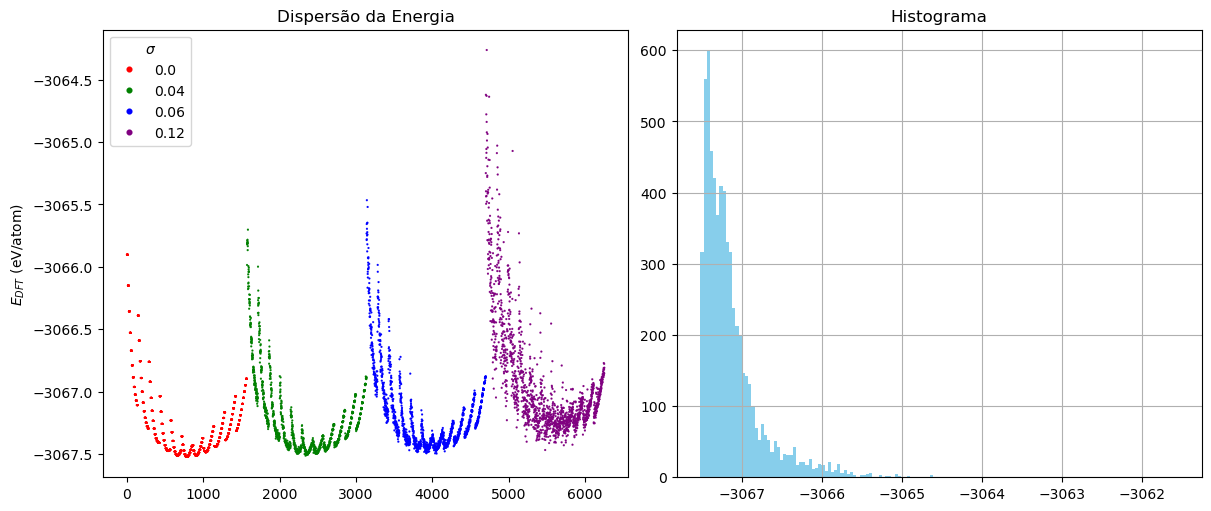

In [ ]:
colors = ["red", "green", "blue", "purple"]

# -- LDA Energies
fig, ax = plt.subplots(ncols=2, figsize=(12, 5), layout="constrained")
ax[0].set_title("Dispersão da Energia")
sns.scatterplot(
    data=energies_LDA.drop(index=4717),
    x="index",
    y="E_DFT (eV/atom)",
    hue="sigma",
    palette=colors,
    ax=ax[0],
    edgecolors=None,
    s=2,
)
ax[0].set_xlabel("")
ax[0].set_ylabel(r"$E_{DFT}$ (eV/atom)")
ax[1].set_title("Histograma")
energies_LDA["E_DFT (eV/atom)"].hist(bins=150, ax=ax[1], color="skyblue")
ax[0].set_xlabel("")
ax[0].legend(title=r"$\sigma$", loc="upper left", markerscale=3)


plt.show()

In [125]:
# energies_LDA[mask_energy_lda] -> bad structures

filtered_energies = energies_LDA[~mask_energy_lda].copy()
filtered_energies

,filename,E_DFT (eV/atom),sigma,index
0,0001-LDA-ZnO-2.88-1.44-111.xsf,-3065.903161,0.00,0
1,0002-LDA-ZnO-2.88-1.44-112.xsf,-3065.903161,0.00,1
2,0003-LDA-ZnO-2.88-1.44-113.xsf,-3065.902937,0.00,2
3,0004-LDA-ZnO-2.88-1.44-211.xsf,-3065.903161,0.00,3
4,0005-LDA-ZnO-2.88-1.44-212.xsf,-3065.903161,0.00,4
...,...,...,...,...
6249,6288-LDA-ZnO-3.52-1.77-311-0.12.xsf,-3066.866888,0.12,6249
6250,6289-LDA-ZnO-3.52-1.77-312-0.12.xsf,-3066.820370,0.12,6250
6251,6290-LDA-ZnO-3.52-1.77-313-0.12.xsf,-3066.777764,0.12,6251
6252,6291-LDA-ZnO-3.52-1.77-321-0.12.xsf,-3066.853101,0.12,6252


## Analisando Forças

In [59]:
metrics = ["mean", "std", "min", "max", "50%", "25%", "75%"]


forces_LDA.iloc[:, 1:5].describe().T[metrics]

,mean,std,min,max,50%,25%,75%
Fx_DFT,1.868034e-10,2.142491,-53.335086,57.768930,0.000000,-0.302842,0.302079
Fy_DFT,4.882400e-11,2.148768,-52.868595,54.391190,0.000000,-0.302978,0.303301
Fz_DFT,2.080311e-10,3.111287,-106.071982,103.296293,-0.000098,-0.686030,0.676486
|F|_DFT,2.344199e+00,3.659545,0.000075,108.241055,1.232799,0.526878,2.751347


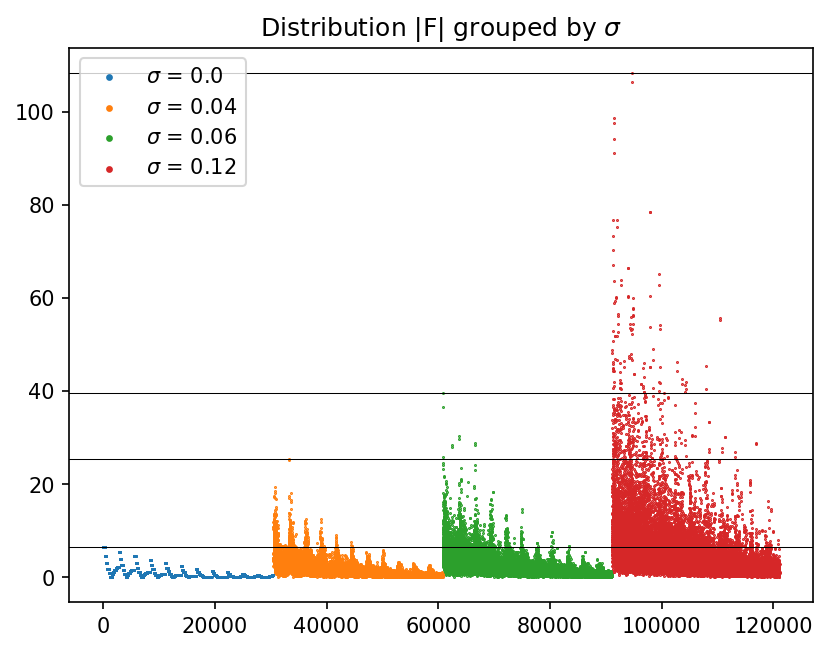

In [117]:
sigma_max_forces = []

plt.figure(dpi=150)
plt.title(r"Distribution |$\mathrm{F}$| grouped by $\sigma$")
for s_val in forces_LDA.sigma.unique():
    sigma_mask = forces_LDA["sigma"] == s_val
    subset = forces_LDA[sigma_mask]
    plt.scatter(subset.index, subset["|F|_DFT"], s=0.2, label=rf"$\sigma$ = {s_val}")
    max_F = subset["|F|_DFT"].max()
    plt.axhline(max_F, lw=0.5, color="k")
    sigma_max_forces.append(max_F)

plt.legend(loc="upper left", markerscale=5)
plt.show()

### Eliminar estruturas baseados em `MAXFORCES`

In [97]:
forces_LDA

,structure,Fx_DFT,Fy_DFT,Fz_DFT,|F|_DFT,sigma,Fi_max
0,0001-LDA-ZnO-2.88-1.44-111.xsf,0.000000,-0.000000,-6.509008,6.509008,0.00,6.509008
1,0001-LDA-ZnO-2.88-1.44-111.xsf,0.000000,0.000000,-6.509008,6.509008,0.00,6.509008
2,0001-LDA-ZnO-2.88-1.44-111.xsf,0.000000,0.000000,6.509008,6.509008,0.00,6.509008
3,0001-LDA-ZnO-2.88-1.44-111.xsf,-0.000000,0.000000,6.509008,6.509008,0.00,6.509008
4,0002-LDA-ZnO-2.88-1.44-112.xsf,0.000000,0.000000,-6.508889,6.508889,0.00,6.508889
...,...,...,...,...,...,...,...
121115,6292-LDA-ZnO-3.52-1.77-331-0.12.xsf,0.215445,-0.140649,1.251463,1.277638,0.12,1.251463
121116,6292-LDA-ZnO-3.52-1.77-331-0.12.xsf,0.597030,-0.490573,-0.610457,0.984766,0.12,0.610457
121117,6292-LDA-ZnO-3.52-1.77-331-0.12.xsf,-2.452928,-1.427605,0.381064,2.863585,0.12,2.452928
121118,6292-LDA-ZnO-3.52-1.77-331-0.12.xsf,-0.615315,0.836909,0.014735,1.038867,0.12,0.836909


In [ ]:
MAXFORCES = sigma_max_forces[2]

mask_bad_component = (
    (forces_LDA["Fx_DFT"].abs() > MAXFORCES)
    | (forces_LDA["Fy_DFT"].abs() > MAXFORCES)
    | (forces_LDA["Fz_DFT"].abs() > MAXFORCES)
)

# estruturas que devem ser eliminadas
bad_structures = forces_LDA.loc[mask_bad_component, "structure"].unique()

# dataframe filtrado: mantém apenas estruturas válidas
filtered_forces = forces_LDA[~forces_LDA["structure"].isin(bad_structures)].copy()
print("Estruturas removidas:")
print(bad_structures)
n_total = forces_LDA["structure"].nunique()
n_removed = len(bad_structures)
n_kept = filtered_forces["structure"].nunique()

print(f"Total de estruturas: {n_total}")
print(f"Removidas: {n_removed}")
print(f"Mantidas: {n_kept}")

Estruturas removidas:
['4726-LDA-ZnO-2.88-1.44-221-0.12.xsf'
 '4730-LDA-ZnO-2.88-1.44-313-0.12.xsf'
 '4731-LDA-ZnO-2.88-1.44-321-0.12.xsf'
 '4732-LDA-ZnO-2.88-1.44-331-0.12.xsf'
 '4736-LDA-ZnO-2.88-1.48-211-0.12.xsf'
 '4745-LDA-ZnO-2.88-1.48-331-0.12.xsf'
 '4755-LDA-ZnO-2.88-1.51-312-0.12.xsf'
 '4763-LDA-ZnO-2.88-1.54-212-0.12.xsf'
 '4769-LDA-ZnO-2.88-1.54-313-0.12.xsf'
 '4770-LDA-ZnO-2.88-1.54-321-0.12.xsf'
 '4771-LDA-ZnO-2.88-1.54-331-0.12.xsf'
 '4794-LDA-ZnO-2.88-1.61-312-0.12.xsf'
 '4795-LDA-ZnO-2.88-1.61-313-0.12.xsf'
 '4804-LDA-ZnO-2.88-1.64-221-0.12.xsf'
 '4829-LDA-ZnO-2.88-1.70-213-0.12.xsf'
 '4865-LDA-ZnO-2.94-1.44-113-0.12.xsf'
 '4869-LDA-ZnO-2.94-1.44-221-0.12.xsf'
 '4877-LDA-ZnO-2.94-1.48-112-0.12.xsf'
 '4888-LDA-ZnO-2.94-1.48-331-0.12.xsf'
 '4896-LDA-ZnO-2.94-1.51-222-0.12.xsf'
 '4897-LDA-ZnO-2.94-1.51-311-0.12.xsf'
 '4906-LDA-ZnO-2.94-1.54-212-0.12.xsf'
 '4907-LDA-ZnO-2.94-1.54-213-0.12.xsf'
 '4909-LDA-ZnO-2.94-1.54-222-0.12.xsf'
 '4910-LDA-ZnO-2.94-1.54-311-0.12.xsf'
 '4

In [118]:
filtered_forces["idx"] = filtered_forces.index
filtered_forces

,structure,Fx_DFT,Fy_DFT,Fz_DFT,|F|_DFT,sigma,Fi_max,idx
0,0001-LDA-ZnO-2.88-1.44-111.xsf,0.000000,-0.000000,-6.509008,6.509008,0.00,6.509008,0
1,0001-LDA-ZnO-2.88-1.44-111.xsf,0.000000,0.000000,-6.509008,6.509008,0.00,6.509008,1
2,0001-LDA-ZnO-2.88-1.44-111.xsf,0.000000,0.000000,6.509008,6.509008,0.00,6.509008,2
3,0001-LDA-ZnO-2.88-1.44-111.xsf,-0.000000,0.000000,6.509008,6.509008,0.00,6.509008,3
4,0002-LDA-ZnO-2.88-1.44-112.xsf,0.000000,0.000000,-6.508889,6.508889,0.00,6.508889,4
...,...,...,...,...,...,...,...,...
121115,6292-LDA-ZnO-3.52-1.77-331-0.12.xsf,0.215445,-0.140649,1.251463,1.277638,0.12,1.251463,121115
121116,6292-LDA-ZnO-3.52-1.77-331-0.12.xsf,0.597030,-0.490573,-0.610457,0.984766,0.12,0.610457,121116
121117,6292-LDA-ZnO-3.52-1.77-331-0.12.xsf,-2.452928,-1.427605,0.381064,2.863585,0.12,2.452928,121117
121118,6292-LDA-ZnO-3.52-1.77-331-0.12.xsf,-0.615315,0.836909,0.014735,1.038867,0.12,0.836909,121118


In [121]:
filtered_forces.structure.nunique()

6215

In [128]:
display(filtered_energies.sample(3))
display(filtered_forces.sample(3))


,filename,E_DFT (eV/atom),sigma,index
3190,3198-LDA-ZnO-2.88-1.54-331-0.06.xsf,-3066.354237,0.06,3190
172,0173-LDA-ZnO-2.94-1.51-211.xsf,-3066.755970,0.00,172
5028,5047-LDA-ZnO-3.00-1.54-113-0.12.xsf,-3066.537198,0.12,5028


,structure,Fx_DFT,Fy_DFT,Fz_DFT,|F|_DFT,sigma,Fi_max,idx
71374,3690-LDA-ZnO-3.07-1.70-313-0.06.xsf,-2.181404,1.501068,-1.493230,3.039978,0.06,2.181404,71374
75098,3883-LDA-ZnO-3.20-1.48-311-0.06.xsf,0.230759,-0.350629,3.080798,3.109262,0.06,3.080798,75098
9284,0480-LDA-ZnO-3.07-1.54-321.xsf,-0.000022,-0.000012,-0.967917,0.967917,0.00,0.967917,9284


In [129]:
structures_energy = set(filtered_energies["filename"])
structures_force = set(filtered_forces["structure"])

structures_common = structures_energy & structures_force

In [131]:
len(structures_common)

6192

In [133]:
structures_common

{'0744-LDA-ZnO-3.20-1.51-113.xsf',
 '4690-LDA-ZnO-3.52-1.70-312-0.06.xsf',
 '0930-LDA-ZnO-3.26-1.61-221.xsf',
 '2095-LDA-ZnO-3.07-1.67-112-0.04.xsf',
 '5263-LDA-ZnO-3.07-1.70-313-0.12.xsf',
 '3747-LDA-ZnO-3.13-1.51-113-0.06.xsf',
 '0960-LDA-ZnO-3.26-1.67-313.xsf',
 '2139-LDA-ZnO-3.07-1.77-221-0.04.xsf',
 '5743-LDA-ZnO-3.32-1.48-312-0.12.xsf',
 '3719-LDA-ZnO-3.13-1.44-111-0.06.xsf',
 '0407-LDA-ZnO-3.00-1.73-211.xsf',
 '1496-LDA-ZnO-3.52-1.61-111.xsf',
 '4972-LDA-ZnO-2.94-1.70-213-0.12.xsf',
 '1193-LDA-ZnO-3.39-1.54-312.xsf',
 '4574-LDA-ZnO-3.45-1.77-313-0.06.xsf',
 '3981-LDA-ZnO-3.20-1.73-113-0.06.xsf',
 '3796-LDA-ZnO-3.13-1.61-331-0.06.xsf',
 '5607-LDA-ZnO-3.26-1.51-211-0.12.xsf',
 '4939-LDA-ZnO-2.94-1.61-321-0.12.xsf',
 '6105-LDA-ZnO-3.45-1.67-222-0.12.xsf',
 '0227-LDA-ZnO-2.94-1.64-213.xsf',
 '3512-LDA-ZnO-3.00-1.64-112-0.06.xsf',
 '4085-LDA-ZnO-3.26-1.64-113-0.06.xsf',
 '2768-LDA-ZnO-3.39-1.54-321-0.04.xsf',
 '6223-LDA-ZnO-3.52-1.61-311-0.12.xsf',
 '3765-LDA-ZnO-3.13-1.54-222-0.06.x

## Criando o dataset LDA clean

In [134]:
from pathlib import Path
import shutil

src_dir = Path("/home/jvc/ZnO_database/data/LDA_dataset")
dst_dir = Path("/home/jvc/ZnO_database/data/LDA_dataset_clean")

dst_dir.mkdir(parents=True, exist_ok=True)

for fname in structures_common:
    src_file = src_dir / fname
    dst_file = dst_dir / fname

    if src_file.exists():
        shutil.copy2(src_file, dst_file)
    else:
        print(f"[WARN] Não encontrado: {src_file}")

# Divisão em treinamento e Validação

In [ ]:
import random


dataset_dir = Path("/home/jvc/ZnO_database/data/LDA_dataset_clean")
train_dir = dataset_dir / "train"
val_dir = dataset_dir / "validation"

train_dir.mkdir(exist_ok=True)
val_dir.mkdir(exist_ok=True)

# lista de estruturas
files = list(dataset_dir.glob("*.xsf"))

# embaralhamento reprodutível
random.seed(42)
random.shuffle(files)

# split 80/20
split_idx = int(0.8 * len(files))
train_files = files[:split_idx]
val_files = files[split_idx:]

# copiar arquivos
for f in train_files:
    shutil.copy2(f, train_dir / f.name)

for f in val_files:
    shutil.copy2(f, val_dir / f.name)

print(f"Train: {len(train_files)}")
print(f"Validation: {len(val_files)}")

Train: 4953
Validation: 1239


---